In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import colors
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output  # clear_output(wait=True)
import time
import os
import sys
import h5py
import myPy_functions as my


import PyPump as pp


# Image file path
img_path = r'PeaceFilmx2_BW_96x151.png'

# Compute Magnitudes Pumping Schemes from Image
image = Image.open(img_path)
img_array = np.array(image)
if ( img_array.ndim == 2 ): #BW
    img_1chan = img_array/np.max(img_array)
else: #RGB
    img_1chan = img_array[:,:,2]/np.max(img_array[:,:,2])  #Blue channel always the best
Nx=img_1chan.shape[0]
Ny=img_1chan.shape[1]
col_sum=np.zeros(Ny)
for i in range(Ny):
    column = img_1chan[:,i]
    col_sum[i] = np.sum(column)
c_max=np.max(col_sum)
c_mean=np.mean(col_sum)
norm_factor = c_max
PumpScheme_k=20*img_1chan/norm_factor

# Physical parameters
Nmodes= Nx
f0 = 4.2                       # Central resonance frequency in GHz
omega0 = 2 * np.pi * f0       # Angular frequency [rad/s]
Delta_f = 0.1e-3              # Mode spacing in GHz
Delta = 2 * np.pi * Delta_f   # Angular frequency spacing

# Loss rates
gamma_int = 0.0                              # Internal loss [GHz]
gamma_ext = 2 * np.pi * 100e6 / 1e9          # External coupling [GHz]
g1_value = 24 	                             # Reference coupling strength
gamma_over_g = 10.0                          # Dissipation-to-coupling ratio

# Compute total decay rate
gamma_r      = g1_value * gamma_over_g       # Reference decay rate
gamma0_ext   = gamma_ext * gamma_r           # Scaled external decay rate
gamma        = gamma_int + gamma0_ext        # Total decay rate
K = np.identity(2 * Nmodes) * np.sqrt(gamma0_ext)
Id = np.eye(2*Nx, dtype=complex)  # Identity matrix of size 2*Nx 

# Change of basis Transformation Matrices: a,a* --U--> x,p
U_2by2= (1/np.sqrt(2))*np.array([[1,  1j],
                                 [1, -1j]])                 # \vec{a} = U\vec{x}
Udag_2by2= (1/np.sqrt(2))*np.array([[ 1,  1 ],
                                    [-1j, 1j]])             # \vec{x} = Udag\vec{a}
U=np.kron(np.eye(Nmodes,dtype=complex),U_2by2)              # nmodes is number of repeated blocks
Udag=np.linalg.inv(U) 

In [4]:
#Value used in the experiment
pump_amp_min = 0.0
pump_amp_max = 0.035 # 0.069
nr_pump_amps = 11
pump_amp_arr = np.linspace(pump_amp_min, pump_amp_max, nr_pump_amps)
amp_val = pump_amp_arr[10]

#Generate Scattering matrix from pump schemes (WARNING: TAKES TIME TO RUN, USE SAVED FILE INSTEAD)
Sa_saved = np.zeros((Ny,Nx,Nx), dtype=complex)
Sref_saved = np.zeros(Ny, dtype=float)
Ap_k_saved = np.zeros((Nx,Ny), dtype=float)
phi_k_saved = np.zeros((Nx,Ny), dtype=float)
omega_k_saved = np.zeros(Nx, dtype=float) 
Npumps = Nx
phi_k = 2*np.pi*np.random.rand(Npumps,Ny) #np.zeros(Npumps)#
k_arr = np.arange(-Nx, 0)
omega_k = 2*omega0 + k_arr * Delta 
omega_k_saved=omega_k
for i in range(Ny):
    Ap_k = PumpScheme_k[:,i]
    gp_k = Ap_k * np.exp(1j*phi_k[:,i]) 
    
    # print(gp_k.shape, k_arr.shape)
    Saa, Sref = my.compute_bigS_from_g(Nmodes, gp_k, omega_k, omega0, Delta) 
    Sa_small= my.extract_small_S(Saa)
    Sa_abs=np.abs(Sa_small)
    Sa_saved[i,:,:]=Sa_small
    Sref_saved[i]=Sref
    Ap_k_saved[:,i]=Ap_k
    phi_k_saved[:,i]=phi_k[:,i]
    
    if i == 40: # Nx//3:
        Saved_eg=Sa_abs
        Saved_ref=Sref

# # Save
# fname='Stargets_Image_PeaceFilmx2_BW_96x151.npz'
# np.savez(fname, omega_k=omega_k_saved, phi_k=phi_k_saved, Ap_k=Ap_k_saved, Sa_saved=Sa_saved, Sref_saved=Sref_saved)


Text(0.5, 1.0, 'dB')

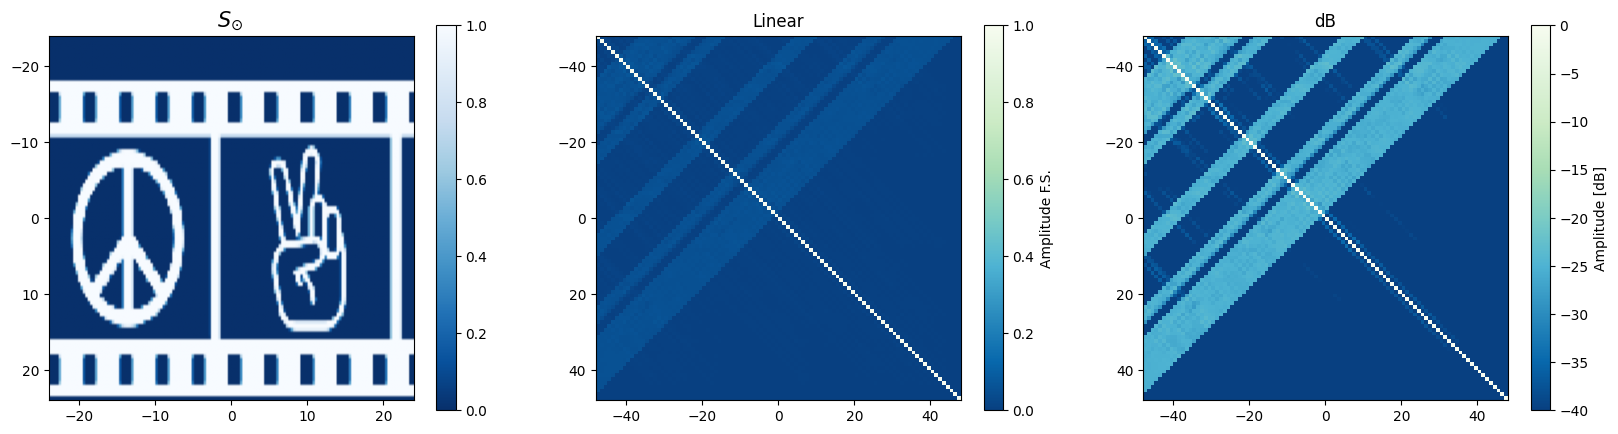

In [ ]:
# # Load
# fname='Stargets_Image_PeaceFilmx2_BW_96x151.npz'
# data = np.load(fname)
# omega_k_saved=data['omega_k']
# phi_k_saved=data['phi_k'] 
# Ap_k_saved=data['Ap_k']
# Sa_saved=data['Sa_saved'] 
# Sref_saved=data['Sref_saved']

# Case Selection
i=40
Sa_small=Sa_saved[i,:,:]
Sref=Sref_saved[i]
Sa_abs=np.abs(Sa_small)
Saved_eg=Sa_abs
Saved_ref=Sref

#Plot
start_mode=0
top=Nmodes//2

fig0, ax0 = plt.subplots(1, 3, figsize=(20,5))
my.plot_Matrix(img_1chan, str='$S_{\odot}$ ', col_map='Blues_r', fig=fig0, ax=ax0[0])
# Linear
pl02=ax0[1].imshow(Saved_eg/Saved_ref, cmap='GnBu_r', extent=[-top, top, top, -top],vmin = 0, vmax = 1)
plt.colorbar(pl02, ax=ax0[1], label='Amplitude F.S.')
ax0[1].set_title('Linear')
# dB
pl02=ax0[2].imshow(my.dB(Saved_eg/Saved_ref + 1e-15), cmap='GnBu_r', extent=[-top, top, top, -top],vmin = -40, vmax = 0)
plt.colorbar(pl02, ax=ax0[2], label='Amplitude [dB]')
ax0[2].set_title('dB')